The four adjacent digits in the 1000-digit number that have the greatest product are 9x9x8x9=5832.

Find the thirteen adjacent digits in the 1000-digit number that have the greatest product. What is the value of this product?

In [1]:
number ='''
73167176531330624919225119674426574742355349194934
96983520312774506326239578318016984801869478851843
85861560789112949495459501737958331952853208805511
12540698747158523863050715693290963295227443043557
66896648950445244523161731856403098711121722383113
62229893423380308135336276614282806444486645238749
30358907296290491560440772390713810515859307960866
70172427121883998797908792274921901699720888093776
65727333001053367881220235421809751254540594752243
52584907711670556013604839586446706324415722155397
53697817977846174064955149290862569321978468622482
83972241375657056057490261407972968652414535100474
82166370484403199890008895243450658541227588666881
16427171479924442928230863465674813919123162824586
17866458359124566529476545682848912883142607690042
24219022671055626321111109370544217506941658960408
07198403850962455444362981230987879927244284909188
84580156166097919133875499200524063689912560717606
05886116467109405077541002256983155200055935729725
71636269561882670428252483600823257530420752963450
'''.replace('\n', '')
n=1_000

# Primer intento:

primer intento basado en slicer de strings de python

In [2]:
import math
def primer_intento():
    n_int = 0
    for i in range(n - 12):
        n_int = max(n_int, math.prod(map(lambda x: int(x), number[i:13+i:])))
    return n_int

primer_intento()

23514624000

# Optimizacion:

chatgpt recomienda usar una ventana deslizante para actualizar el producto en cada paso y tratar los ceros aparte, pero trabajando directamente sobre el string para no reservar una lista adicional de digitos:

In [3]:
def optimizacion():
    ancho = 13
    resultado = 0
    producto = 1
    ceros = 0
    izquierda = 0

    for derecha, caracter in enumerate(number):
        digito = ord(caracter) - 48
        if digito == 0:
            ceros += 1
        else:
            producto *= digito

        if derecha - izquierda + 1 > ancho:
            saliente = ord(number[izquierda]) - 48
            if saliente == 0:
                ceros -= 1
            else:
                producto //= saliente
            izquierda += 1

        if derecha - izquierda + 1 == ancho and ceros == 0:
            if producto > resultado:
                resultado = producto

    return resultado

optimizacion()

23514624000

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 23514624000
Consistente: True
Repeticiones por corrida: 10
Tiempo promedio:  1.1583 ms
Tiempo mediano:   1.1641 ms
Tiempo minimo:    1.1268 ms
Tiempo stdev:     21.3216 us  (CV: 1.8%)
Memoria promedio: 1.1953 KB
Memoria mediana:  1.2031 KB
Memoria maxima:   1.2969 KB
Memoria stdev:    95.5545 B
Asignaciones (mediana): 3

--- Optimizacion ---
Resultado: 23514624000
Consistente: True
Repeticiones por corrida: 100
Tiempo promedio:  173.5597 us
Tiempo mediano:   172.8360 us
Tiempo minimo:    170.3576 us
Tiempo stdev:     2.7368 us  (CV: 1.6%)
Memoria promedio: 1.0430 KB
Memoria mediana:  1.0469 KB
Memoria maxima:   1.1875 KB
Memoria stdev:    134.7393 B
Asignaciones (mediana): 6

=== Comparacion directa ===
Speedup en tiempo:    6.74x  (gana: Optimizacion)
Ratio de memoria:     1.15x  (gana: Optimizacion)
Ratio asignaciones:   2.00x  (gana: Primer intento)


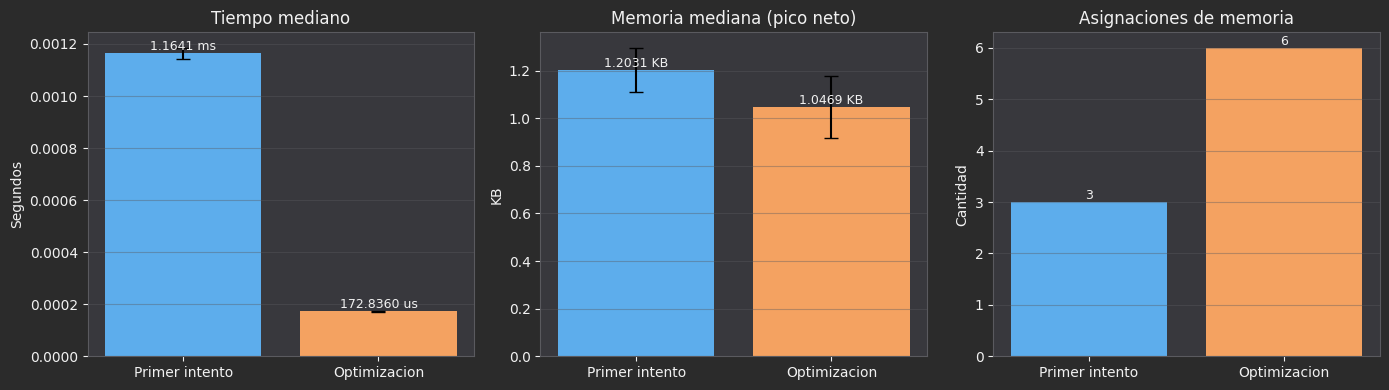

{'Primer intento': {'resultado': 23514624000,
  'consistente': True,
  'tiempos': [0.001186430500000002,
   0.0011764368000000136,
   0.001136020900000001,
   0.0011670017000000143,
   0.0011611298000000047,
   0.0011406248000000118,
   0.001126836599999992,
   0.0011716998000000033],
  'memorias': [1.296875, 1.234375, 1.171875, 1.078125],
  'asignaciones': [3, 3, 3, 3],
  'repeticiones': 10},
 'Optimizacion': {'resultado': 23514624000,
  'consistente': True,
  'tiempos': [0.0001753583999999986,
   0.00017538376999999715,
   0.00017384095999999793,
   0.00017183113999999833,
   0.00017035764000000064,
   0.00017169042999999994,
   0.00017148193000000145,
   0.00017853346000000326],
  'memorias': [1.109375, 1.1875, 0.984375, 0.890625],
  'asignaciones': [6, 7, 6, 6],
  'repeticiones': 100}}

In [4]:
from lib.utils import comparar_metodos

comparar_metodos(primer_intento, optimizacion)